In [1]:
from importlib import reload
import dataset
reload(dataset)

<module 'dataset' from '/home/tymek/mini/wavfile_analyzer/code/dataset.py'>

In [2]:
from training import train
from cnn import CNN
from dataset import *
from config import Config

from torch import optim

In [4]:
train_loader, val_loader, class_map = load_dataset(train_fraction=1)
# batch shape: torch.Size([64, 99, 13])

In [5]:
cnn = CNN(input_fdim=13, input_tdim=99)

In [6]:
optimizer = optim.Adam(cnn.parameters(), lr=0.0002, weight_decay=0.0001)

In [ ]:
results_cnn, model_cnn = train(cnn, train_loader, val_loader, optimizer=optimizer, epochs=20, patience=5)

Device: cuda


100%|██████████| 267/267 [00:21<00:00, 12.33it/s]


Epoch [1/20], Train Loss: 0.3414, Val Loss: 0.3793, Train score: 0.90, Val score: 0.88


100%|██████████| 267/267 [00:19<00:00, 13.82it/s]


Epoch [2/20], Train Loss: 0.2593, Val Loss: 0.2948, Train score: 0.92, Val score: 0.91


...

Epoch [13/20], Train Loss: 0.0515, Val Loss: 0.2577, Train score: 0.99, Val score: 0.93


100%|██████████| 267/267 [00:20<00:00, 13.07it/s]


Epoch [14/20], Train Loss: 0.0455, Val Loss: 0.1840, Train score: 0.99, Val score: 0.95


100%|██████████| 267/267 [00:16<00:00, 16.11it/s]


Epoch [15/20], Train Loss: 0.0394, Val Loss: 0.2184, Train score: 0.99, Val score: 0.94
Early stopping triggered


In [12]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def print_confusion_matrix(model, data_loader, name="", save=False):
    
    int_to_class = {v: k for k, v in class_map.items()}

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            try:
                inputs = inputs.to('cuda')
                labels = labels.to('cuda')
            except:
                pass
            
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    labels_str = [int_to_class[i] for i in range(len(int_to_class))]

    
    plt.figure(figsize=(10, 8))  

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_str)
    disp.plot(xticks_rotation=45, cmap='Blues', ax=plt.gca())
    plt.title("Confusion Matrix")
    plt.tight_layout()
    if save:
        plt.savefig(f"../results/confmatrix_{name}.png")
    plt.show()

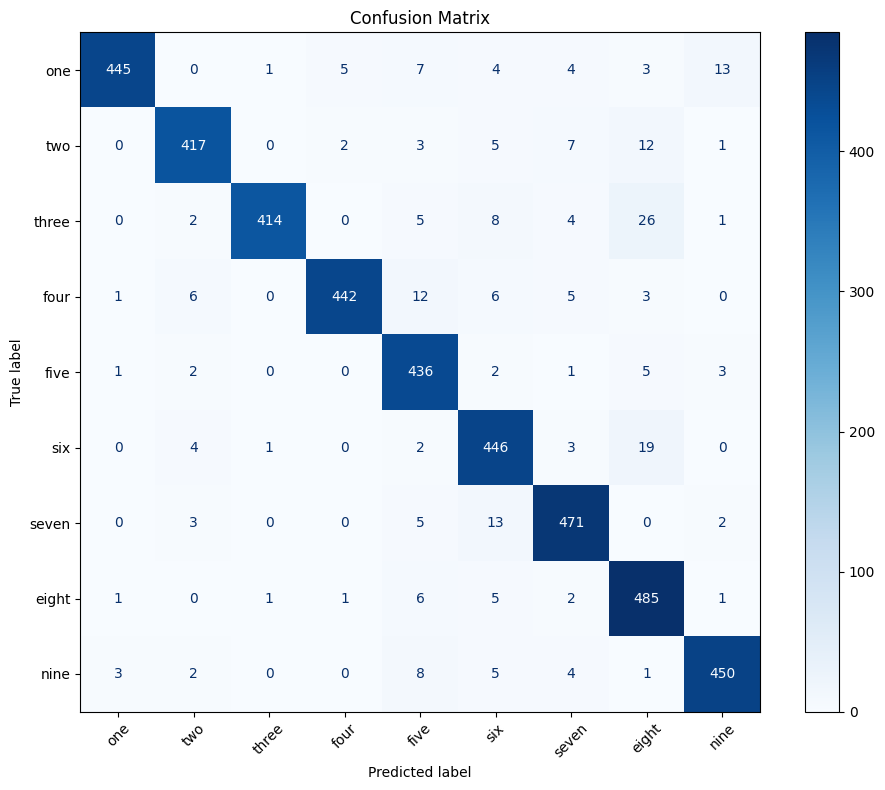

In [13]:
print_confusion_matrix(cnn, val_loader, name='cnn', save=True)

In [24]:
n = 5
results = []
for i in range(n):
    print(f"Iteration {i+1}/{n}")
    cnn = CNN(input_fdim=13, input_tdim=99)
    optimizer = optim.Adam(cnn.parameters(), lr=0.0002, weight_decay=0.0001)
    results_cnn, model_cnn = train(cnn, train_loader, val_loader, optimizer=optimizer, epochs=15, patience=5)
    results.append(results_cnn)
    print(f"\n")

Iteration 1/5
Device: cuda


  0%|          | 0/267 [00:00<?, ?it/s]

100%|██████████| 267/267 [00:20<00:00, 12.95it/s]


Epoch [1/15], Train Loss: 1.1663, Val Loss: 0.6914, Train score: 0.61, Val score: 0.78


100%|██████████| 267/267 [00:17<00:00, 15.26it/s]


...

Epoch [13/15], Train Loss: 0.0597, Val Loss: 0.1801, Train score: 0.98, Val score: 0.95


100%|██████████| 267/267 [00:14<00:00, 18.15it/s]


Epoch [14/15], Train Loss: 0.0527, Val Loss: 0.1928, Train score: 0.98, Val score: 0.95


100%|██████████| 267/267 [00:24<00:00, 10.84it/s]


Epoch [15/15], Train Loss: 0.0502, Val Loss: 0.2150, Train score: 0.99, Val score: 0.94




In [41]:
import pandas as pd

def load_results(results_raw, name='mfcc'):
    """ loads results """
    results = {}
    ex_results = []
    for i, result in enumerate(results_raw):
        data_i = pd.DataFrame(result)
        ex_results.append((data_i, f"iteration_{i+1}"))
    results[name] = ex_results
    return results

def get_best_iteration(data):
    """ returns row with best validation score """
    return data.loc[data['val_score'].idxmax()]

def get_experiment_results(exp_results):
    """
    calculates means of best scores from conducted experiments

    Returns:
        tuple[pd.Series, pd.Series]: mean, std
    """
    agg_results = pd.DataFrame()
    for res, name in exp_results:
        best = get_best_iteration(res).to_frame().T
        best['name'] = name
        if agg_results.empty:
            agg_results = best.copy()
        else:
            agg_results = pd.concat([agg_results, best])
    return agg_results

In [42]:
r = load_results(results)

In [45]:
best = get_experiment_results(r['mfcc'])
best

,train_loss,val_loss,train_score,val_score,name
12,0.066557,0.187842,0.979685,0.944340,iteration_1
14,0.047302,0.189920,0.985674,0.949272,iteration_2
13,0.049821,0.167872,0.985439,0.953499,iteration_3
10,0.084419,0.171906,0.972581,0.949272,iteration_4
12,0.059720,0.180128,0.982621,0.951620,iteration_5


In [ ]:
train_loss = best['train_loss'].to_numpy()
val_loss = best['val_loss'].to_numpy()
train_score = best['train_score'].to_numpy()
val_score = best['val_score'].to_numpy()

In [5]:
print("Train Loss:   mean =", np.round(np.mean(train_loss), 3), " std =", np.round(np.std(train_loss), 3))
print("Val Loss:     mean =", np.round(np.mean(val_loss), 3), " std =", np.round(np.std(val_loss), 3))
print("Train Score:  mean =", np.round(np.mean(train_score), 3), " std =", np.round(np.std(train_score), 3))
print("Val Score:    mean =", np.round(np.mean(val_score), 3), " std =", np.round(np.std(val_score), 3))

Train Loss:   mean = 0.062  std = 0.013
Val Loss:     mean = 0.18  std = 0.009
Train Score:  mean = 0.981  std = 0.005
Val Score:    mean = 0.95  std = 0.003
